In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
CA1_path <- paste0(indir,"/05_H3K9me3_Allsubclass/CA1/")
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_CT.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L2_3.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L4_Rorb.mm10.tmp"
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L5.mm10.tmp"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L6.mm10.tmp"     
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_NP.mm10.tmp"     
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_HC_CA1.mm10.tmp"    
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_HC_CA23.mm10.tmp"   
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_HC_DG.mm10.tmp"     
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_In_CGE.mm10.tmp"    
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_In_Pvalb.mm10.tmp"  
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K9me3_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K9me3_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K9me3_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K9me3_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,CT_signal_sum,CT_signal_sum_log10,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,⋯,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,CGE_signal_sum,CGE_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,78.89592,1.902525,37.69918,1.587702,6.221136,0.8586055,17.36592,1.264013,17.16560,⋯,64.075016,1.8134143,91.95419,1.968269,73.88143,1.874374,49.36283,1.702110,42.94742,1.642933
chr1:3868330-3869330,173.39760,2.241541,57.91780,1.770247,155.528200,2.1945926,28.46860,1.469360,34.33120,⋯,8.049600,0.9566294,100.94760,2.008377,107.24720,2.034417,275.46200,2.441635,94.73680,1.981079
chr1:4000851-4001851,10.83740,1.073256,21.06100,1.343625,12.960600,1.1449041,56.93740,1.762959,137.32520,⋯,16.099200,1.2329758,22.94260,1.379171,47.66540,1.687220,154.25860,2.191056,0.00000,0.000000
chr1:4017553-4018553,214.20041,2.332843,81.89046,1.918505,156.901934,2.1983874,74.18927,1.876156,51.49700,⋯,48.297600,1.6928258,77.51872,1.894973,226.41000,2.356810,100.33426,2.005756,198.20569,2.299302
chr1:4168027-4169027,43.34940,1.646888,168.48800,2.229139,77.764000,1.8963278,85.40600,1.936544,17.16560,⋯,40.248000,1.6154029,110.12480,2.045811,190.66180,2.282536,396.66600,2.599518,205.26400,2.314423
chr1:4249638-4250638,230.57601,2.364694,197.72021,2.298242,47.150990,1.6826052,111.91025,2.052733,182.60805,⋯,184.448934,2.2682243,253.80082,2.406201,174.43166,2.244108,151.21759,2.182465,294.28402,2.470240
chr1:4454449-4455449,119.21080,2.079943,89.50920,1.956693,25.921400,1.4300976,49.82020,1.706036,0.00000,⋯,201.240000,2.3058671,68.82800,1.844030,11.91640,1.111141,77.12940,1.892814,47.36840,1.684562
chr1:4794017-4795017,216.74800,2.337954,84.24400,1.930664,129.606800,2.1159658,142.34320,2.156377,68.66260,⋯,177.091600,2.2506434,22.94260,1.379171,178.74540,2.254658,88.14780,1.950111,189.47360,2.279835
chr1:5336791-5337791,260.09600,2.416800,173.75340,2.242426,116.646200,2.0705779,42.70300,1.640511,120.15960,⋯,112.694600,2.0557398,339.55200,2.532183,285.99200,2.457870,286.48000,2.458608,584.21000,2.767312


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.902525,1.587702,0.8586055,1.264013,1.259250,1.047213,1.419094,1.8134143,1.968269,1.874374,1.702110,1.642933
chr1:3868330-3869330,2.241541,1.770247,2.1945926,1.469360,1.548158,2.773047,2.050720,0.9566294,2.008377,2.034417,2.441635,1.981079
chr1:4000851-4001851,1.073256,1.343625,1.1449041,1.762959,2.140901,2.327204,0.000000,1.2329758,1.379171,1.687220,2.191056,0.000000
chr1:4017553-4018553,2.332843,1.918505,2.1983874,1.876156,1.720134,2.037242,1.474667,1.6928258,1.894973,2.356810,2.005756,2.299302
chr1:4168027-4169027,1.646888,2.229139,1.8963278,1.936544,1.259250,1.636337,1.012094,1.6154029,2.045811,2.282536,2.599518,2.314423
chr1:4249638-4250638,2.364694,2.298242,1.6826052,2.052733,2.263892,1.636337,2.162441,2.2682243,2.406201,2.244108,2.182465,2.470240
chr1:4454449-4455449,2.079943,1.956693,1.4300976,1.706036,0.000000,0.000000,1.460101,2.3058671,1.844030,1.111141,1.892814,1.684562
chr1:4794017-4795017,2.337954,1.930664,2.1159658,2.156377,1.843000,1.932322,1.876556,2.2506434,1.379171,2.254658,1.950111,2.279835
chr1:5336791-5337791,2.416800,2.242426,2.0705779,1.640511,2.083358,2.627212,2.117114,2.0557398,2.532183,2.457870,2.458608,2.767312


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.902525,1.587702,0.8586055,1.264013,1.259250,1.047213,1.419094,1.8134143,1.968269,1.874374,1.702110,1.642933
chr1:3868330-3869330,2.241541,1.770247,2.1945926,1.469360,1.548158,2.773047,2.050720,0.9566294,2.008377,2.034417,2.441635,1.981079
chr1:4000851-4001851,1.073256,1.343625,1.1449041,1.762959,2.140901,2.327204,0.000000,1.2329758,1.379171,1.687220,2.191056,0.000000
chr1:4017553-4018553,2.332843,1.918505,2.1983874,1.876156,1.720134,2.037242,1.474667,1.6928258,1.894973,2.356810,2.005756,2.299302
chr1:4168027-4169027,1.646888,2.229139,1.8963278,1.936544,1.259250,1.636337,1.012094,1.6154029,2.045811,2.282536,2.599518,2.314423
chr1:4249638-4250638,2.364694,2.298242,1.6826052,2.052733,2.263892,1.636337,2.162441,2.2682243,2.406201,2.244108,2.182465,2.470240
chr1:4454449-4455449,2.079943,1.956693,1.4300976,1.706036,0.000000,0.000000,1.460101,2.3058671,1.844030,1.111141,1.892814,1.684562
chr1:4794017-4795017,2.337954,1.930664,2.1159658,2.156377,1.843000,1.932322,1.876556,2.2506434,1.379171,2.254658,1.950111,2.279835
chr1:5336791-5337791,2.416800,2.242426,2.0705779,1.640511,2.083358,2.627212,2.117114,2.0557398,2.532183,2.457870,2.458608,2.767312


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,CT,L2_3,L4_Rorb,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.902525,1.587702,0.8586055,1.264013,1.259250,1.047213,1.419094,1.8134143,1.968269,1.874374,1.702110,1.642933
chr1:3868330-3869330,2.241541,1.770247,2.1945926,1.469360,1.548158,2.773047,2.050720,0.9566294,2.008377,2.034417,2.441635,1.981079
chr1:4000851-4001851,1.073256,1.343625,1.1449041,1.762959,2.140901,2.327204,0.000000,1.2329758,1.379171,1.687220,2.191056,0.000000
chr1:4017553-4018553,2.332843,1.918505,2.1983874,1.876156,1.720134,2.037242,1.474667,1.6928258,1.894973,2.356810,2.005756,2.299302
chr1:4168027-4169027,1.646888,2.229139,1.8963278,1.936544,1.259250,1.636337,1.012094,1.6154029,2.045811,2.282536,2.599518,2.314423
chr1:4249638-4250638,2.364694,2.298242,1.6826052,2.052733,2.263892,1.636337,2.162441,2.2682243,2.406201,2.244108,2.182465,2.470240
chr1:4454449-4455449,2.079943,1.956693,1.4300976,1.706036,0.000000,0.000000,1.460101,2.3058671,1.844030,1.111141,1.892814,1.684562
chr1:4794017-4795017,2.337954,1.930664,2.1159658,2.156377,1.843000,1.932322,1.876556,2.2506434,1.379171,2.254658,1.950111,2.279835
chr1:5336791-5337791,2.416800,2.242426,2.0705779,1.640511,2.083358,2.627212,2.117114,2.0557398,2.532183,2.457870,2.458608,2.767312


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,CT,L2_3,L4,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.902525,1.587702,0.8586055,1.264013,1.259250,1.047213,1.419094,1.8134143,1.968269,1.874374,1.702110,1.642933
chr1:3868330-3869330,2.241541,1.770247,2.1945926,1.469360,1.548158,2.773047,2.050720,0.9566294,2.008377,2.034417,2.441635,1.981079
chr1:4000851-4001851,1.073256,1.343625,1.1449041,1.762959,2.140901,2.327204,0.000000,1.2329758,1.379171,1.687220,2.191056,0.000000
chr1:4017553-4018553,2.332843,1.918505,2.1983874,1.876156,1.720134,2.037242,1.474667,1.6928258,1.894973,2.356810,2.005756,2.299302
chr1:4168027-4169027,1.646888,2.229139,1.8963278,1.936544,1.259250,1.636337,1.012094,1.6154029,2.045811,2.282536,2.599518,2.314423
chr1:4249638-4250638,2.364694,2.298242,1.6826052,2.052733,2.263892,1.636337,2.162441,2.2682243,2.406201,2.244108,2.182465,2.470240
chr1:4454449-4455449,2.079943,1.956693,1.4300976,1.706036,0.000000,0.000000,1.460101,2.3058671,1.844030,1.111141,1.892814,1.684562
chr1:4794017-4795017,2.337954,1.930664,2.1159658,2.156377,1.843000,1.932322,1.876556,2.2506434,1.379171,2.254658,1.950111,2.279835
chr1:5336791-5337791,2.416800,2.242426,2.0705779,1.640511,2.083358,2.627212,2.117114,2.0557398,2.532183,2.457870,2.458608,2.767312


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,CT,L2_3,L4,NP,CA1,CA23,DG,CGE,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.902525,1.587702,0.8586055,1.047213,1.419094,1.8134143,1.968269,1.874374,1.702110,1.642933,1.2616312
chr1:3868330-3869330,2.241541,1.770247,2.1945926,2.773047,2.050720,0.9566294,2.008377,2.034417,2.441635,1.981079,1.5087589
chr1:4000851-4001851,1.073256,1.343625,1.1449041,2.327204,0.000000,1.2329758,1.379171,1.687220,2.191056,0.000000,1.9519302
chr1:4017553-4018553,2.332843,1.918505,2.1983874,2.037242,1.474667,1.6928258,1.894973,2.356810,2.005756,2.299302,1.7981452
chr1:4168027-4169027,1.646888,2.229139,1.8963278,1.636337,1.012094,1.6154029,2.045811,2.282536,2.599518,2.314423,1.5978968
chr1:4249638-4250638,2.364694,2.298242,1.6826052,1.636337,2.162441,2.2682243,2.406201,2.244108,2.182465,2.470240,2.1583126
chr1:4454449-4455449,2.079943,1.956693,1.4300976,0.000000,1.460101,2.3058671,1.844030,1.111141,1.892814,1.684562,0.8530182
chr1:4794017-4795017,2.337954,1.930664,2.1159658,1.932322,1.876556,2.2506434,1.379171,2.254658,1.950111,2.279835,1.9996884
chr1:5336791-5337791,2.416800,2.242426,2.0705779,2.627212,2.117114,2.0557398,2.532183,2.457870,2.458608,2.767312,1.8619345


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "NP"    "CT"    "DG"    "CGE"  
[10] "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.587702,0.8586055,1.2616312,1.419094,1.8134143,1.047213,1.902525,1.968269,1.874374,1.702110,1.642933
chr1:3868330-3869330,1.770247,2.1945926,1.5087589,2.050720,0.9566294,2.773047,2.241541,2.008377,2.034417,2.441635,1.981079
chr1:4000851-4001851,1.343625,1.1449041,1.9519302,0.000000,1.2329758,2.327204,1.073256,1.379171,1.687220,2.191056,0.000000
chr1:4017553-4018553,1.918505,2.1983874,1.7981452,1.474667,1.6928258,2.037242,2.332843,1.894973,2.356810,2.005756,2.299302
chr1:4168027-4169027,2.229139,1.8963278,1.5978968,1.012094,1.6154029,1.636337,1.646888,2.045811,2.282536,2.599518,2.314423
chr1:4249638-4250638,2.298242,1.6826052,2.1583126,2.162441,2.2682243,1.636337,2.364694,2.406201,2.244108,2.182465,2.470240
chr1:4454449-4455449,1.956693,1.4300976,0.8530182,1.460101,2.3058671,0.000000,2.079943,1.844030,1.111141,1.892814,1.684562
chr1:4794017-4795017,1.930664,2.1159658,1.9996884,1.876556,2.2506434,1.932322,2.337954,1.379171,2.254658,1.950111,2.279835
chr1:5336791-5337791,2.242426,2.0705779,1.8619345,2.117114,2.0557398,2.627212,2.416800,2.532183,2.457870,2.458608,2.767312


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
.,1.776526,1.679229,1.668389,1.670804,1.676766,1.304188,1.715889,1.753564,1.721042,1.773078,1.671424


In [19]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3", "L4", "L5", "CA1", "CA23", "NP", "CT", "DG", "CGE", "Pvalb", "Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K9me3_path <- paste0(indir,"/05_H3K9me3_Allsubclass/")

In [21]:
subdirs <- list.dirs(path = H3K9me3_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//CT"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//DG"   
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//L2_3" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//L4_5" 
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//L5"   
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//Lamp5"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//NP"   
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//Pvalb"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//Sncg" 
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/05_H3K9me3_Allsubclass//Sst"

In [22]:
basename(subdirs)

[1] "CA1"   "CA23"  "CT"    "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "NP"   
[10] "Pvalb" "Sncg"  "Sst"

In [ ]:
L2_3 <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/L2_3'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"
[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:40205252-40206252,2.1395536,2.4711923,2.4474181,2.645371,2.3883083,2.969076,2.353660,2.391956,2.434991,2.4867718,2.201109
chr1:63801436-63802436,1.4774397,1.5549754,0.4778006,1.373128,1.7070575,0.000000,1.219126,1.218210,1.159618,1.0798467,1.719418
chr1:95910578-95911578,1.9306638,1.7229858,2.1486392,2.367464,2.1132539,0.000000,1.819703,1.922173,1.395026,1.3624259,2.242254
chr1:121992418-121993418,2.1395536,2.3188352,2.1409026,1.972311,1.9894293,2.106718,2.117431,1.711586,2.079773,2.0460454,1.981079
chr1:123860055-123861055,1.9812503,2.2909472,1.9069595,2.271020,2.1640345,1.636337,2.292416,2.549391,1.983765,2.1590863,1.902804
chr1:127035082-127036082,1.9235784,1.8111769,1.8486680,2.211135,1.6928258,2.327204,2.241541,1.736853,1.427925,1.5321860,1.495326
chr1:165699424-165700424,1.8366277,1.8530816,0.9833890,1.460101,1.6819116,0.000000,1.073256,0.000000,1.395026,1.0798467,1.594102
chr1:184865166-184866166,1.6925055,1.4944934,1.4206079,1.753537,1.8498746,0.000000,1.355543,1.853402,1.926418,1.5321860,1.225035
chr2:10595247-10596247,1.2252007,1.7229858,1.7243646,1.237340,1.2807479,0.000000,1.355543,1.455320,1.563554,1.4545421,1.225035


In [24]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.402197,1.270822,1.306183,1.441514,1.313517,1.030115,1.312554,1.419318,1.345936,1.356394,1.199932


In [ ]:
L4_5 <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/L4_5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3989606-3990606,1.861170,1.763048,2.1296495,1.753537,1.6775263,2.660078,1.494358,2.226387,2.034417,1.824649,2.174136
chr1:7536517-7537517,1.634699,1.818248,1.7415467,1.291471,0.9566294,1.932322,1.525200,1.748672,1.782342,2.191056,0.000000
chr1:9780815-9781815,1.513106,1.600777,0.9291832,1.675885,1.8659717,0.000000,1.819703,1.379171,1.860327,1.653926,1.807249
chr1:14839073-14840073,2.009421,1.906638,2.1135119,2.172719,1.0339246,0.000000,2.045150,1.915688,1.782342,1.391741,1.225035
chr1:14914779-14915779,1.873400,2.019886,1.7745180,1.753537,1.8155578,0.000000,1.942994,1.626308,1.687220,1.653926,1.807249
chr1:17756423-17757423,1.436579,0.000000,1.7236851,0.000000,1.8155578,0.000000,1.073256,1.711586,1.687220,1.079847,1.512938
chr1:22023298-22024298,1.851364,1.539653,2.0760810,1.876556,1.6399522,2.230806,2.124979,1.923744,1.999487,1.971272,1.774171
chr1:23137109-23138109,2.041190,1.880463,1.6003896,1.532529,1.8554694,1.908276,1.635163,1.740853,1.828032,1.938248,0.000000
chr1:26269966-26270966,2.161224,2.200663,2.1779670,2.150748,2.0864235,2.106718,1.664564,2.410653,2.515886,2.407472,2.600341


In [26]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L4_5,1.699338,1.58083,1.562556,1.618576,1.635262,1.240628,1.619967,1.701495,1.654468,1.658372,1.581699


In [ ]:
L5 <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/L5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4185672-4186672,1.7153811,1.721277,2.0947769,1.614623,1.4438740,1.851405,2.0389125,2.045236,1.717610,2.016852,1.8072495
chr1:9994550-9995550,1.5131057,0.000000,1.4112812,1.291471,0.0000000,0.000000,1.0732563,1.671038,0.000000,1.748904,1.5129377
chr1:20083023-20084023,2.1422152,1.965300,1.8572674,2.274484,2.0536130,1.655428,2.4009791,2.082552,2.399622,1.833303,1.6878103
chr1:22220457-22221457,1.5781439,1.600777,1.2287823,2.013282,0.9566294,0.000000,1.3555435,2.169771,2.439453,1.362426,1.8072495
chr1:25591789-25592789,1.5553904,1.818248,0.7903914,2.121890,1.8481423,1.636337,1.3972698,1.781026,1.681332,1.766541,1.9697592
chr1:26496284-26497284,2.5080986,2.726228,2.5412509,2.559919,2.4259220,2.530558,2.4987019,2.734357,2.554477,2.750464,2.3464547
chr1:27086331-27087331,2.4862661,1.962487,2.3974555,2.331415,2.3058671,2.668511,1.9935958,2.344883,2.356810,2.124575,2.2011091
chr1:27631906-27632906,1.6346989,1.144904,1.6351392,1.291471,1.2698053,0.000000,0.0000000,1.686732,1.395026,2.218119,0.0000000
chr1:27648468-27649468,2.2012813,2.511905,2.3410272,2.050720,2.3846903,2.472748,2.2136782,2.508123,2.192881,2.548502,2.4042040


In [28]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L5,1.646072,1.489602,1.458946,1.563904,1.56904,1.119013,1.505401,1.641503,1.597735,1.585915,1.504441


In [ ]:
CA1 <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/CA1'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,1.587702,0.8586055,1.2616312,1.419094,1.8134143,1.047213,1.902525,1.968269,1.874374,1.702110,1.642933
chr1:3868330-3869330,1.770247,2.1945926,1.5087589,2.050720,0.9566294,2.773047,2.241541,2.008377,2.034417,2.441635,1.981079
chr1:4000851-4001851,1.343625,1.1449041,1.9519302,0.000000,1.2329758,2.327204,1.073256,1.379171,1.687220,2.191056,0.000000
chr1:4017553-4018553,1.918505,2.1983874,1.7981452,1.474667,1.6928258,2.037242,2.332843,1.894973,2.356810,2.005756,2.299302
chr1:4168027-4169027,2.229139,1.8963278,1.5978968,1.012094,1.6154029,1.636337,1.646888,2.045811,2.282536,2.599518,2.314423
chr1:4249638-4250638,2.298242,1.6826052,2.1583126,2.162441,2.2682243,1.636337,2.364694,2.406201,2.244108,2.182465,2.470240
chr1:4454449-4455449,1.956693,1.4300976,0.8530182,1.460101,2.3058671,0.000000,2.079943,1.844030,1.111141,1.892814,1.684562
chr1:4794017-4795017,1.930664,2.1159658,1.9996884,1.876556,2.2506434,1.932322,2.337954,1.379171,2.254658,1.950111,2.279835
chr1:5336791-5337791,2.242426,2.0705779,1.8619345,2.117114,2.0557398,2.627212,2.416800,2.532183,2.457870,2.458608,2.767312


In [30]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA1,1.776526,1.679229,1.668389,1.670804,1.676766,1.304188,1.715889,1.753564,1.721042,1.773078,1.671424


In [ ]:
CA23 <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/CA23'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3151305-3152305,2.3767979,2.241904,2.2047771,2.325645,2.374553,2.539664,1.9829585,2.463919,2.232660,2.317912,2.606156
chr1:3776523-3777523,1.7295908,2.229141,1.9376023,1.927067,1.952045,2.106718,1.9429937,2.080272,2.475538,2.046045,1.902804
chr1:4031436-4032436,1.5591286,1.909005,1.4632068,1.190823,1.400517,2.472748,1.4377477,1.493028,1.898830,2.194983,2.047377
chr1:4057009-4058009,1.8410679,0.000000,1.9555270,1.925347,0.000000,2.115674,2.2904677,1.191737,1.690082,1.375319,1.509132
chr1:4065207-4066207,1.5435162,1.938583,2.3220309,1.584944,1.649146,2.706223,1.4339528,2.319303,2.168195,2.255181,1.627205
chr1:4072107-4073107,1.9566927,2.290947,2.1823386,1.972311,1.865972,1.636337,1.9429937,2.141939,2.282536,2.124575,1.684562
chr1:4118129-4119129,2.1715129,1.722986,1.7595389,1.675885,1.692826,2.406046,2.0799435,1.626308,2.420220,1.532186,2.242254
chr1:4149321-4150321,0.6603978,1.547063,0.4547031,1.012094,0.000000,2.150537,1.8223319,1.248253,1.655918,1.064862,1.225035
chr1:4342915-4343915,2.3362115,1.600777,2.0659239,2.117114,1.815558,0.000000,2.1519383,2.112199,2.120837,2.274883,2.314423


In [32]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA23,1.730731,1.59231,1.587115,1.627176,1.61778,1.236744,1.633298,1.664602,1.63842,1.697239,1.570015


In [ ]:
NP <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/NP'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

NP

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4035689-4036689,1.1806512,1.891513,1.0085037,0.0000000,1.0626958,2.472748,1.566820,1.3791713,1.7487879,2.1985118,0.000000
chr1:4933311-4934311,1.6346989,1.144904,0.8332276,1.8765561,1.6154029,0.000000,1.993596,1.5633463,1.6154604,1.5321860,1.225035
chr1:6077804-6078804,2.2227240,1.136767,1.8406035,0.8100988,1.0197944,2.472748,2.124414,1.0407888,0.9034592,2.1308511,2.258133
chr1:6367459-6368459,1.7225434,1.722986,1.4487316,1.8465655,1.3446693,2.197738,2.176256,1.7976627,1.1111415,2.1536111,2.104882
chr1:7734392-7735392,1.6847305,2.070578,1.7417555,0.0000000,1.7585137,1.932322,1.885708,2.4485517,2.0797729,2.1245753,0.000000
chr1:9367457-9368457,2.3613738,2.303915,1.8744154,2.3786666,2.0983767,0.000000,2.054591,2.4146119,2.2309601,2.3851708,2.273597
chr1:9905254-9906254,1.5625241,2.070578,1.7431835,0.5260456,2.1815521,2.230806,1.073256,1.8784187,1.7823422,1.0798467,1.225035
chr1:10079108-10080108,2.0872424,1.928017,0.8124796,1.4122845,2.0490469,1.636337,1.509761,1.5135403,1.7730168,1.6303669,1.684562
chr1:10298443-10299443,1.8416610,2.019886,0.8814795,1.5812600,0.9566294,0.000000,1.885708,1.8145100,0.0000000,2.0870826,2.314423


In [34]:
NP_mean <- colMeans(NP) %>% data.frame() %>% t()
rownames(NP_mean) <- "NP"
NP_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
NP,1.697971,1.556535,1.53985,1.611611,1.623707,1.063949,1.554943,1.668475,1.585516,1.630198,1.469757


In [ ]:
CT <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/CT'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CT

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3908393-3909393,1.225201,0.0000000,0.5914127,1.5812600,1.2329758,2.581567,0.000000,1.7115862,1.565246,1.5321860,1.512938
chr1:5417353-5418353,2.016324,1.6767201,1.8131029,1.7095753,1.4889991,2.147017,1.564646,2.1112899,1.967677,2.3162048,1.876825
chr1:5957907-5958907,1.729591,1.8617571,0.9563042,1.7535371,1.9190437,0.000000,1.907910,2.0520244,2.254658,2.4432421,2.176335
chr1:9594969-9595969,1.513106,0.0000000,0.0000000,1.4601007,0.9566294,0.000000,2.038913,0.0000000,1.565246,2.1590863,1.684562
chr1:11620744-11621744,1.061852,0.0000000,0.6746524,1.5812600,1.6154029,0.000000,1.073256,1.6263075,1.395026,1.0798467,1.225035
chr1:11728492-11729492,1.729591,1.1449041,1.5347196,1.5812600,1.6928258,0.000000,1.525200,1.3791713,1.395026,1.0798467,1.225035
chr1:20849555-20850555,2.226093,2.2779362,1.9057897,2.0425733,1.7005581,2.548061,1.073256,2.3784948,1.905378,2.3022120,1.616393
chr1:20922610-20923610,1.902975,1.7229858,1.6417235,2.0132823,1.7585137,1.636337,1.073256,2.0083770,1.395026,1.6539261,1.684562
chr1:23933700-23934700,2.171513,2.1836682,1.9817209,2.4591258,2.1918774,2.197155,2.138463,2.4672970,2.053131,2.0239742,1.919628


In [36]:
CT_mean <- colMeans(CT) %>% data.frame() %>% t()
rownames(CT_mean) <- "CT"
CT_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CT,1.681676,1.517755,1.507288,1.612923,1.615698,1.118182,1.568999,1.666747,1.595576,1.675992,1.586873


In [ ]:
DG <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/DG'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:5012521-5013521,1.578144,1.6007769,0.8530182,1.012094,1.4005173,0.000000,1.646888,1.0076198,1.395026,1.362426,0.0000000
chr1:6862606-6863606,2.004492,2.1945926,1.8522677,1.972311,1.9520452,2.106718,1.741835,2.1419387,2.034417,1.826792,1.9028043
chr1:7358520-7359520,2.047549,1.8182483,2.3540082,2.621907,2.3846903,2.472748,2.151938,2.6264882,2.356810,2.087083,2.3464547
chr1:13910825-13911825,1.684730,1.8963278,1.9228856,2.050720,1.9520452,2.627212,2.292416,1.8976546,1.983765,2.274883,2.2798348
chr1:16814367-16815367,1.873400,1.6007769,1.6967552,2.225521,1.9894293,1.932322,1.741835,1.1692511,1.111141,2.366214,2.2422536
chr1:17029988-17030988,1.770712,1.8988929,1.3164635,1.879758,2.3234167,2.108438,1.889367,2.1136737,2.036705,1.999573,2.1055281
chr1:17078363-17079363,2.171513,2.2291410,2.0971572,2.085185,2.0557398,2.327204,2.151938,2.1419387,2.420220,2.191056,2.2422536
chr1:19954555-19955555,1.930664,0.0000000,2.2361611,1.927067,1.8155578,2.327204,1.646888,1.6710376,2.224867,1.362426,1.2250352
chr1:27743954-27744954,2.520482,2.5062922,2.2150279,2.333141,1.9285430,2.623208,2.046759,1.9297821,2.168159,2.162128,2.4540573


In [38]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
DG,1.747399,1.625054,1.601735,1.67018,1.630387,1.245538,1.627104,1.653423,1.670173,1.726654,1.608918


In [ ]:
Lamp5 <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/Lamp5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Lamp5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3033026-3034026,2.2539943,2.542301,2.4180491,2.330926,2.337465,2.472748,2.414450,2.501402,2.490782,1.998230,2.4797495
chr1:3116806-3117806,1.4365792,1.962487,0.7346798,1.012094,0.000000,0.000000,1.646888,1.169251,1.565246,1.748904,1.5129377
chr1:3235621-3236621,2.1105131,2.167668,1.8415228,1.424892,1.946663,2.327204,1.855011,2.151223,2.247634,2.262407,1.9810789
chr1:3290843-3291843,1.9812503,2.019886,2.1500189,2.013282,2.305867,1.932322,1.073256,1.967410,2.158352,2.046045,1.8072495
chr1:3510333-3511333,1.8733997,2.290947,1.8985136,2.085185,2.209494,1.636337,1.819703,1.967410,1.983765,1.892814,1.8072495
chr1:3802417-3803417,2.3568019,2.494233,2.0580415,2.400749,2.339133,2.327204,2.359046,2.469330,2.524601,2.248698,2.7177138
chr1:3889972-3890972,2.1432522,2.260278,2.2862163,2.200138,1.909935,2.230806,1.889124,2.158796,1.991222,1.828784,2.4571797
chr1:4330502-4331502,1.9306638,1.962487,1.0843280,1.581260,1.232976,1.636337,1.885708,1.814510,1.687220,1.362426,1.6845617
chr1:4344260-4345260,2.2424256,0.000000,1.9569295,1.675885,1.692826,2.230806,2.079943,2.008377,2.158352,2.000721,2.2798348


In [40]:
Lamp5_mean <- colMeans(Lamp5) %>% data.frame() %>% t()
rownames(Lamp5_mean) <- "Lamp5"
Lamp5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Lamp5,1.774308,1.659398,1.668253,1.68123,1.689872,1.298056,1.682292,1.7377,1.66272,1.720738,1.619813


In [ ]:
Sncg <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/Sncg'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sncg

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3239626-3240626,1.877117,1.501999,0.7707414,1.291471,1.8889609,2.327204,1.299806,1.990867,1.72527551,2.051264,0.8391785
chr1:3597956-3598956,1.632359,2.015129,2.0930485,2.348225,2.0135354,0.000000,2.071243,1.748672,2.07596630,2.122992,2.1048823
chr1:3845937-3846937,1.800634,2.009603,1.9960254,1.964114,1.7546561,1.636337,1.932730,2.149899,1.85123837,2.043325,1.8004632
chr1:7206724-7207724,1.930664,2.290947,1.9151421,2.292099,1.8659717,1.636337,2.117431,2.297338,2.28253556,1.950111,2.3762885
chr1:7289662-7290662,2.299508,2.361903,2.2366130,2.183710,2.4259220,2.406046,2.009448,2.424098,2.23389980,2.086534,2.6564208
chr1:7546590-7547590,1.873400,0.000000,0.5914127,2.085185,1.2329758,1.932322,0.000000,1.626308,0.00000000,1.748904,0.0000000
chr1:7550117-7551117,2.186652,1.722986,1.7415467,2.312203,1.9520452,2.472748,1.646888,2.008377,0.00000000,2.087083,2.0473769
chr1:7583286-7584286,2.102533,2.219538,2.2681574,2.255319,2.4918929,2.374035,2.137573,2.341028,2.20233675,2.014174,2.4156762
chr1:7777255-7778255,1.459003,1.751332,1.7415467,1.789676,2.0490782,0.000000,1.593905,2.205778,2.17561410,2.105859,2.2978176


In [42]:
Sncg_mean <- colMeans(Sncg) %>% data.frame() %>% t()
rownames(Sncg_mean) <- "Sncg"
Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sncg,1.739695,1.601252,1.608765,1.609965,1.637951,1.208857,1.630023,1.678151,1.573806,1.654859,1.53411


In [43]:
rownames(Lamp5_mean) <- "CGE"
rownames(Sncg_mean) <- "CGE"
Lamp5_mean;Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.774308,1.659398,1.668253,1.68123,1.689872,1.298056,1.682292,1.7377,1.66272,1.720738,1.619813


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.739695,1.601252,1.608765,1.609965,1.637951,1.208857,1.630023,1.678151,1.573806,1.654859,1.53411


In [44]:
identical(rownames(Lamp5_mean),rownames(Sncg_mean))
identical(colnames(Lamp5_mean),colnames(Sncg_mean))

[1] TRUE

[1] TRUE

In [45]:
CGE_mean <- (Lamp5_mean+Sncg_mean)/2
CGE_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.757002,1.630325,1.638509,1.645598,1.663911,1.253457,1.656157,1.707926,1.618263,1.687798,1.576962


In [ ]:
Pvalb <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/Pvalb'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3168678-3169678,1.578144,1.722986,1.9547901,2.050720,1.5211172,2.106718,1.355543,2.3169846,1.565246,1.950111,2.314423
chr1:3188267-3189267,1.513106,1.600777,1.5588080,1.012094,0.9566294,0.000000,1.646888,1.7828380,1.860327,2.191056,1.512938
chr1:3189154-3190154,1.513106,1.530125,1.5554850,0.947086,1.0123833,0.000000,1.594863,1.7828380,1.849193,2.191056,1.544199
chr1:3229735-3230735,2.138557,2.220250,2.1324856,1.291471,1.9496965,0.000000,2.100214,2.1071679,2.148722,2.157091,1.961671
chr1:3257828-3258828,1.513106,1.787779,1.2679344,1.885673,1.7478997,1.932322,1.985301,1.9940704,1.565246,1.788347,0.000000
chr1:3275051-3276051,1.738199,1.885254,1.6501371,2.173314,1.9089441,2.318295,1.940248,2.2474044,2.329745,1.950111,1.907157
chr1:3277592-3278592,1.908204,1.677194,1.7430675,2.052152,1.8368381,2.106718,1.920526,2.2709051,2.159787,1.842478,1.886728
chr1:3343546-3344546,1.861988,1.600777,1.7889507,1.824973,1.7471489,1.305295,1.355543,1.8882723,1.782342,2.017680,1.807249
chr1:3345473-3346473,1.768146,1.441242,1.8087539,1.901181,1.5267666,0.000000,1.837647,1.8543234,1.782342,1.866362,1.692151


In [47]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Pvalb,1.690514,1.554658,1.556783,1.586368,1.609435,1.125596,1.584216,1.661004,1.568724,1.579082,1.465822


In [ ]:
Sst <- process_files(paste0(indir,'/05_H3K9me3_Allsubclass/Sst'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3074178-3075178,1.3436252,1.600777,1.3643046,1.291471,2.0238489,0.000000,1.646888,1.520088,1.9264176,1.653926,2.2798348
chr1:3083989-3084989,1.7291217,1.893963,2.2009520,2.013282,2.0567533,2.230806,1.945349,2.307057,2.0816638,1.653926,1.9818661
chr1:3091016-3092016,1.5752348,2.155799,2.2572322,1.748962,1.8138438,2.667880,2.078060,2.351816,1.7809732,2.085199,1.6777028
chr1:3096626-3097626,1.5131057,1.896328,1.7892504,1.581260,1.7585137,2.581567,1.819703,2.156078,2.0797729,1.532186,1.2250352
chr1:3098325-3099325,1.5131057,1.430098,0.7816563,1.675885,1.6928258,2.472748,1.819703,2.045811,2.0344167,1.532186,1.2250352
chr1:3104126-3105126,1.8074200,1.144904,1.6555587,1.972311,1.8155578,2.106718,1.646888,1.844030,2.0344167,1.826792,0.0000000
chr1:3105267-3106267,1.8610440,1.144904,1.6625664,1.972311,1.8010451,2.315730,1.617585,1.844030,1.9800968,1.845425,0.7173184
chr1:3133078-3134078,2.2024019,1.430098,1.5453361,1.876556,1.7632428,2.306488,1.386774,1.787934,1.3950257,1.762013,1.8072495
chr1:3135638-3136638,2.2154335,1.546423,1.7694894,2.020648,1.9594002,2.051337,1.897190,2.032962,1.5110184,2.104957,1.8072495


In [49]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sst,1.704021,1.576441,1.578778,1.595401,1.629513,1.166378,1.600617,1.679179,1.586083,1.625207,1.450659


In [50]:
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,NP_mean,CT_mean,DG_mean,CGE_mean,Pvalb_mean,Sst_mean)

In [51]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.402197,1.270822,1.306183,1.441514,1.313517,1.030115,1.312554,1.419318,1.345936,1.356394,1.199932
L4_5,1.699338,1.580830,1.562556,1.618576,1.635262,1.240628,1.619967,1.701495,1.654468,1.658372,1.581699
L5,1.646072,1.489602,1.458946,1.563904,1.569040,1.119013,1.505401,1.641503,1.597735,1.585915,1.504441
CA1,1.776526,1.679229,1.668389,1.670804,1.676766,1.304188,1.715889,1.753564,1.721042,1.773078,1.671424
CA23,1.730731,1.592310,1.587115,1.627176,1.617780,1.236744,1.633298,1.664602,1.638420,1.697239,1.570015
NP,1.697971,1.556535,1.539850,1.611611,1.623707,1.063949,1.554943,1.668475,1.585516,1.630198,1.469757


[1] 11 11

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.402197,1.270822,1.306183,1.441514,1.313517,1.030115,1.312554,1.419318,1.345936,1.356394,1.199932
L4_5,1.699338,1.580830,1.562556,1.618576,1.635262,1.240628,1.619967,1.701495,1.654468,1.658372,1.581699
L5,1.646072,1.489602,1.458946,1.563904,1.569040,1.119013,1.505401,1.641503,1.597735,1.585915,1.504441
CA1,1.776526,1.679229,1.668389,1.670804,1.676766,1.304188,1.715889,1.753564,1.721042,1.773078,1.671424
CA23,1.730731,1.592310,1.587115,1.627176,1.617780,1.236744,1.633298,1.664602,1.638420,1.697239,1.570015
NP,1.697971,1.556535,1.539850,1.611611,1.623707,1.063949,1.554943,1.668475,1.585516,1.630198,1.469757
CT,1.681676,1.517755,1.507288,1.612923,1.615698,1.118182,1.568999,1.666747,1.595576,1.675992,1.586873
DG,1.747399,1.625054,1.601735,1.670180,1.630387,1.245538,1.627104,1.653423,1.670173,1.726654,1.608918
CGE,1.757002,1.630325,1.638509,1.645598,1.663911,1.253457,1.656157,1.707926,1.618263,1.687798,1.576962
Pvalb,1.690514,1.554658,1.556783,1.586368,1.609435,1.125596,1.584216,1.661004,1.568724,1.579082,1.465822


In [52]:
heatmap_matrix <- as.matrix(all)

In [53]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.402197,1.270822,1.306183,1.441514,1.313517,1.030115,1.312554,1.419318,1.345936,1.356394,1.199932
L4_5,1.699338,1.580830,1.562556,1.618576,1.635262,1.240628,1.619967,1.701495,1.654468,1.658372,1.581699
L5,1.646072,1.489602,1.458946,1.563904,1.569040,1.119013,1.505401,1.641503,1.597735,1.585915,1.504441
CA1,1.776526,1.679229,1.668389,1.670804,1.676766,1.304188,1.715889,1.753564,1.721042,1.773078,1.671424
CA23,1.730731,1.592310,1.587115,1.627176,1.617780,1.236744,1.633298,1.664602,1.638420,1.697239,1.570015
NP,1.697971,1.556535,1.539850,1.611611,1.623707,1.063949,1.554943,1.668475,1.585516,1.630198,1.469757
CT,1.681676,1.517755,1.507288,1.612923,1.615698,1.118182,1.568999,1.666747,1.595576,1.675992,1.586873
DG,1.747399,1.625054,1.601735,1.670180,1.630387,1.245538,1.627104,1.653423,1.670173,1.726654,1.608918
CGE,1.757002,1.630325,1.638509,1.645598,1.663911,1.253457,1.656157,1.707926,1.618263,1.687798,1.576962
Pvalb,1.690514,1.554658,1.556783,1.586368,1.609435,1.125596,1.584216,1.661004,1.568724,1.579082,1.465822


In [54]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [55]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,-0.743722611,-0.22163605,0.31832494,-0.07091959,-1.01028696,2.7584144,-0.02536150,-0.7452487,-0.31583092,-0.01926254,0.07552952
L4_5,-1.179000105,-0.55930493,-1.05431544,-0.74321281,-0.04162197,1.9197681,0.01723204,0.7846728,1.05202576,-0.87398449,0.67774103
L5,0.205526460,-0.51667522,-1.61597870,-0.70412877,0.51103211,-0.6188343,-0.98661459,0.9726779,1.57579987,-0.06100277,1.23819793
CA1,-1.374263770,0.06621649,0.38030896,-0.59690198,-1.97764097,1.6134030,0.66519570,-0.1036346,0.61390326,0.41742042,0.29599347
CA23,0.249051106,-0.23076650,0.03243232,-0.27734907,-1.31668328,1.8470753,0.58654111,-1.8796445,0.05088308,0.88236874,0.05609173
NP,0.628193168,0.41158716,0.15901074,0.60514295,0.93079560,-2.6946765,-0.27020415,0.6679459,-0.01729073,0.18278230,-0.60328643
CT,-0.055385968,-0.90308615,-1.11847283,0.45098648,0.54399424,-1.7829091,-0.26925108,0.4057672,-0.04873429,1.10866532,1.66842619
DG,0.007288034,0.21524890,-0.17259554,1.47980039,-1.01637277,0.6953577,-0.57118468,-2.2323572,0.47483300,0.72606889,0.39391326
CGE,0.327917708,0.39827838,1.42798264,0.05591662,0.07089926,1.2711335,0.39838183,-0.1659046,-2.12173957,-0.84152350,-0.82134226
Pvalb,0.791186751,0.66659094,0.99639106,-0.49207359,0.99567105,-1.4784744,0.73394002,0.7981896,-0.61644869,-1.41401608,-0.98095665


In [56]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


In [57]:
library(grid)

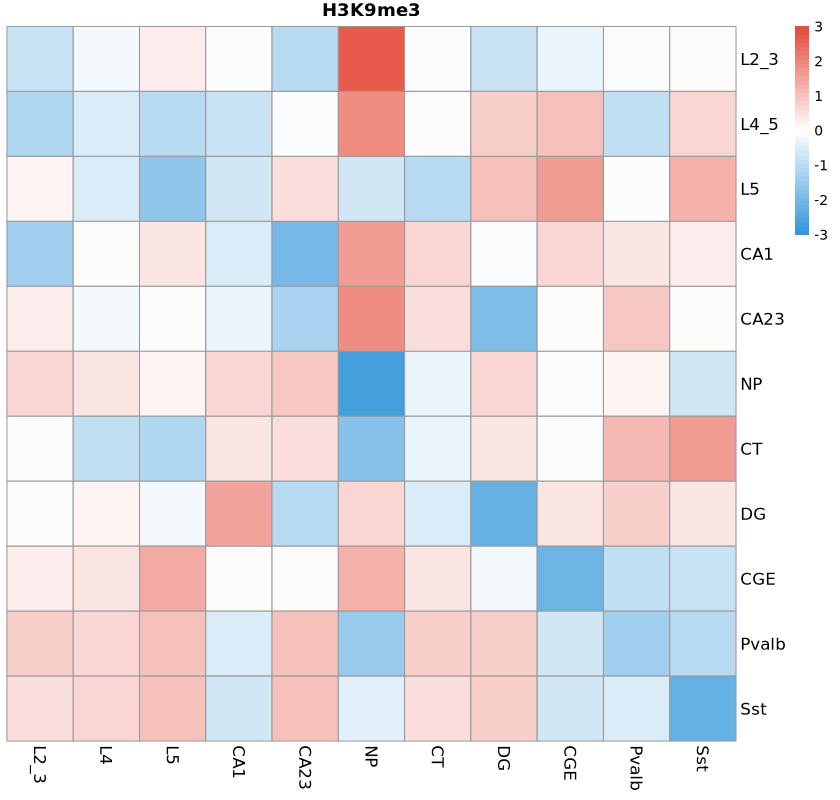

In [58]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K9me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

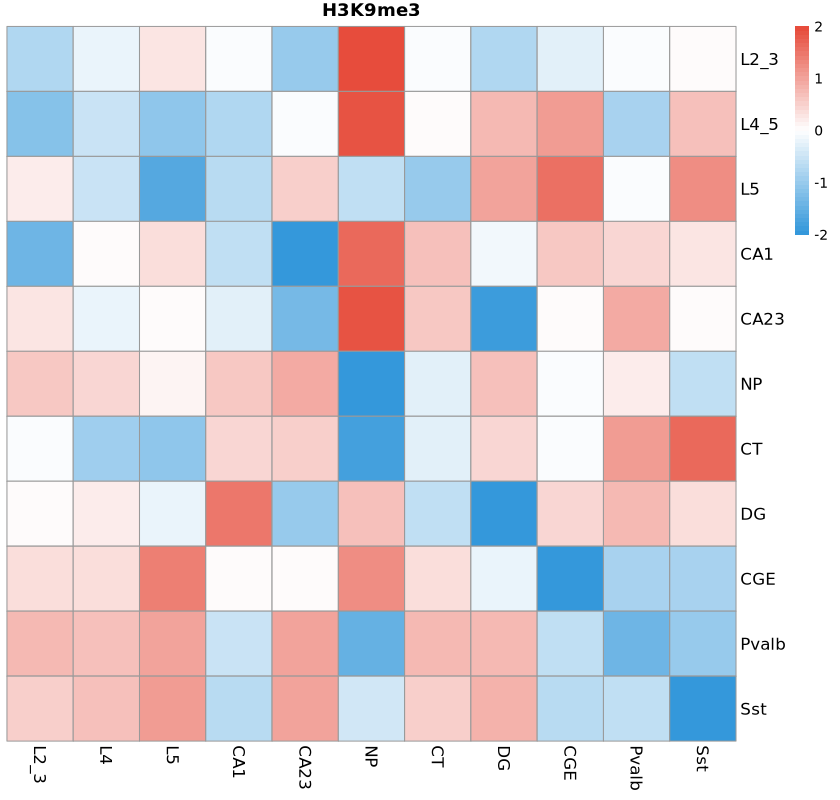

In [59]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K9me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

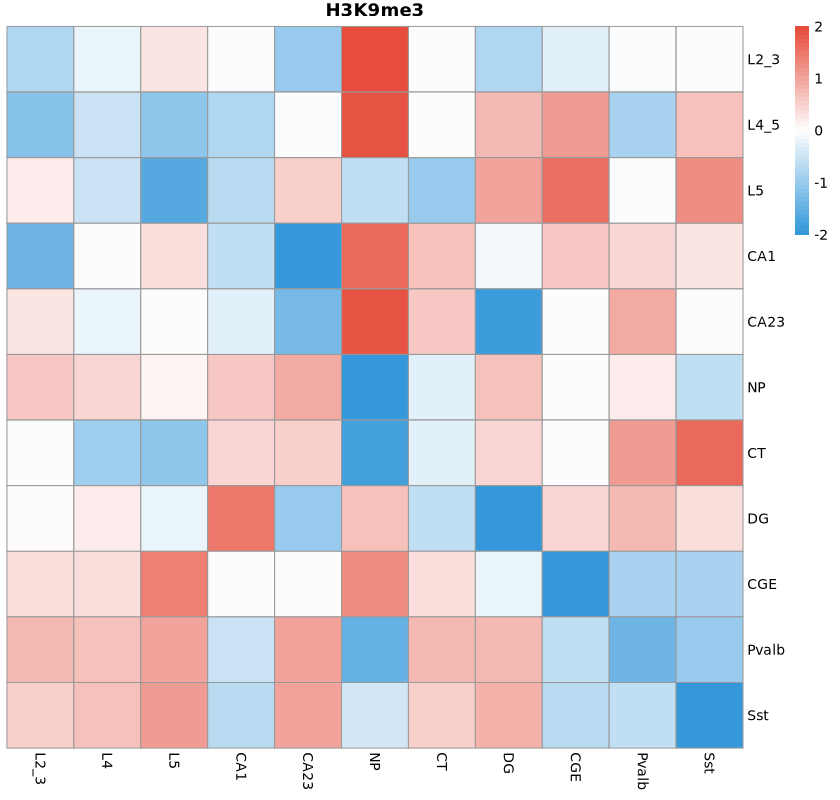

In [60]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K9me3",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

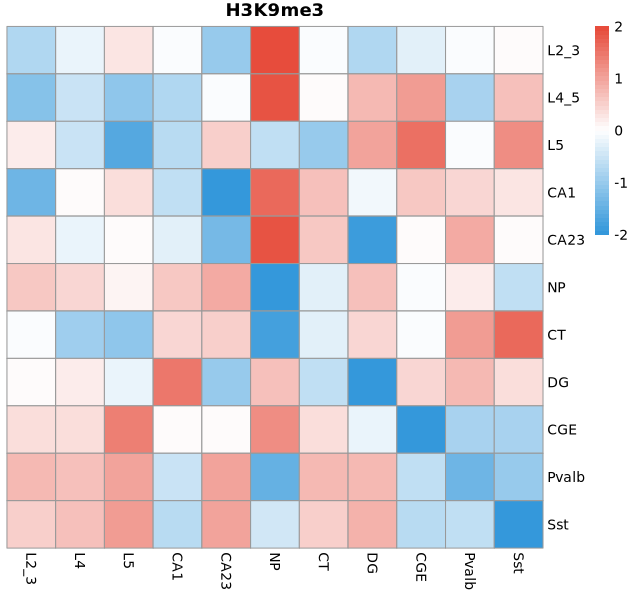

In [61]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
p1

In [ ]:
pdf("../../../output/01-youth/07-Histone/01-heatmap/10-H3K9me3_modification_in_hyperDHMR_merge_v3.pdf",width = 6.4,height = 6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!